In [1]:
import yaml
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
with open("../config.yaml",'r') as file:
    config = yaml.safe_load(file)

In [3]:
bf = pd.read_csv(config['data']['clean']['file2'], quotechar='"', sep = ";")
bf.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y', 'previously_contacted'],
      dtype='str')

In [4]:
bf['converted']= bf.y.apply([lambda x: 0 if x=='no' else 1])

In [5]:
bf.converted.value_counts()

converted
0    39922
1     5289
Name: count, dtype: int64

In [6]:
bf.y.value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

In [7]:
bf.groupby('job')['converted'].mean().sort_values
#chi squared test

<bound method Series.sort_values of job
admin.           0.122027
blue-collar      0.072750
entrepreneur     0.082717
housemaid        0.087903
management       0.137556
retired          0.227915
self-employed    0.118429
services         0.088830
student          0.286780
technician       0.110570
unemployed       0.155027
unknown          0.118056
Name: converted, dtype: float64>

In [8]:
bf.groupby(['education'])['converted'].mean().sort_values
#chi-squared test

<bound method Series.sort_values of education
primary      0.086265
secondary    0.105594
tertiary     0.150064
unknown      0.135703
Name: converted, dtype: float64>

In [9]:
bf.groupby(['marital'])['converted'].mean().sort_values

<bound method Series.sort_values of marital
divorced    0.119455
married     0.101235
single      0.149492
Name: converted, dtype: float64>

In [10]:
bf.groupby(['marital','education'])['converted'].mean().sort_values
#interesting that single with tertiary is most likely to convert, generally seeing higher values for combinations

<bound method Series.sort_values of marital   education
divorced  primary      0.138298
          secondary    0.103375
          tertiary     0.138001
          unknown      0.142012
married   primary      0.075486
          secondary    0.094699
          tertiary     0.129724
          unknown      0.122414
single    primary      0.106682
          secondary    0.129213
          tertiary     0.183639
          unknown      0.162879
Name: converted, dtype: float64>

In [11]:
bf.groupby(['month'])['converted'].mean().sort_values
#chi squared test

<bound method Series.sort_values of month
apr    0.196794
aug    0.110133
dec    0.467290
feb    0.166478
jan    0.101212
jul    0.090935
jun    0.102228
mar    0.519916
may    0.067195
nov    0.101511
oct    0.437669
sep    0.464594
Name: converted, dtype: float64>

<Axes: xlabel='balance', ylabel='Count'>

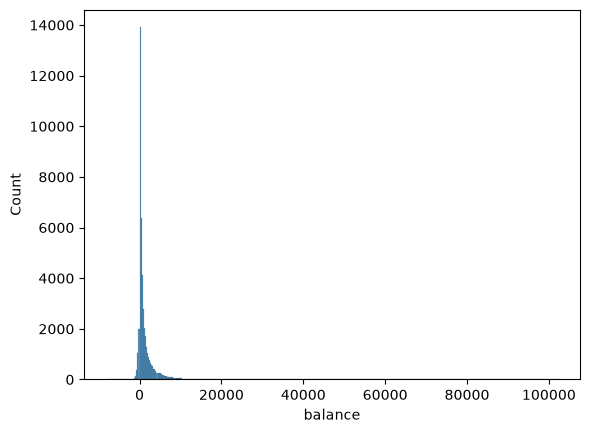

In [12]:
sns.histplot(bf.balance)

In [13]:
bf.balance.min()

np.int64(-8019)

In [14]:
bf['balance_log'] = np.sign(bf['balance']) * np.log1p(np.abs(bf['balance']))

In [15]:
bf['balance_negative'] = (bf['balance'] < 0).astype(int)
print(bf.groupby('balance_negative')['converted'].mean())

balance_negative
0    0.122548
1    0.055762
Name: converted, dtype: float64


In [16]:
print(bf.groupby('month')['balance_negative'].mean().sort_values(ascending=False))
print(bf.groupby('month')['converted'].mean())

month
jul    0.124583
may    0.120878
jun    0.074143
jan    0.068425
feb    0.052473
aug    0.047703
apr    0.047067
nov    0.040050
mar    0.014675
sep    0.008636
oct    0.005420
dec    0.004673
Name: balance_negative, dtype: float64
month
apr    0.196794
aug    0.110133
dec    0.467290
feb    0.166478
jan    0.101212
jul    0.090935
jun    0.102228
mar    0.519916
may    0.067195
nov    0.101511
oct    0.437669
sep    0.464594
Name: converted, dtype: float64


In [17]:
bf.pdays.value_counts()

pdays
-1      36954
 182      167
 92       147
 91       126
 183      126
        ...  
 541        1
 543        1
 871        1
 550        1
 530        1
Name: count, Length: 559, dtype: int64

In [18]:
bf.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y', 'previously_contacted', 'converted',
       'balance_log', 'balance_negative'],
      dtype='str')

In [19]:
features = ['age','job','marital','education', 'default','housing','loan', 'previously_contacted', 'balance_negative','balance_log','converted']

In [39]:
bf.select_dtypes('number').corr()

,age,education,default,balance,housing,loan,day,duration,campaign,pdays,previous,previously_contacted,converted,balance_log,balance_negative
age,1.000000,-0.173615,-0.017879,0.097783,-0.185513,-0.015655,-0.009120,-0.004648,0.004760,-0.023758,0.001288,0.000753,0.025155,0.069922,-0.041329
education,-0.173615,1.000000,-0.009035,0.050572,-0.038689,0.004307,0.021661,0.002554,0.000194,0.007092,0.025295,0.036341,0.051341,0.040194,-0.038126
default,-0.017879,-0.009035,1.000000,-0.066745,-0.006025,0.077234,0.009424,-0.010021,0.016822,-0.029979,-0.018329,-0.039519,-0.022419,-0.226080,0.223867
balance,0.097783,0.050572,-0.066745,1.000000,-0.068768,-0.084350,0.004503,0.021560,-0.014578,0.003435,0.016674,0.030213,0.052838,0.433618,-0.166323
housing,-0.185513,-0.038689,-0.006025,-0.068768,1.000000,0.041323,-0.027982,0.005075,-0.023599,0.124178,0.037076,0.063650,-0.139173,-0.083314,0.103859
loan,-0.015655,0.004307,0.077234,-0.084350,0.041323,1.000000,0.011370,-0.012412,0.009980,-0.022754,-0.011043,-0.031212,-0.068185,-0.144146,0.132364
day,-0.009120,0.021661,0.009424,0.004503,-0.027982,0.011370,1.000000,-0.030206,0.162490,-0.093044,-0.051710,-0.086174,-0.028348,-0.022345,0.022939
duration,-0.004648,0.002554,-0.010021,0.021560,0.005075,-0.012412,-0.030206,1.000000,-0.084570,-0.001565,0.001203,0.003590,0.394521,0.030452,-0.007101
campaign,0.004760,0.000194,0.016822,-0.014578,-0.023599,0.009980,0.162490,-0.084570,1.000000,-0.088628,-0.032855,-0.107973,-0.073172,-0.036270,0.015848
pdays,-0.023758,0.007092,-0.029979,0.003435,0.124178,-0.022754,-0.093044,-0.001565,-0.088628,1.000000,0.454820,0.870442,0.103621,0.037961,-0.014703


In [20]:
bf.nunique(), bf.dtypes, features

(age                       77
 job                       12
 marital                    3
 education                  4
 default                    2
 balance                 7168
 housing                    2
 loan                       2
 contact                    3
 day                       31
 month                     12
 duration                1573
 campaign                  48
 pdays                    559
 previous                  41
 poutcome                   4
 y                          2
 previously_contacted       2
 converted                  2
 balance_log             7168
 balance_negative           2
 dtype: int64,
 age                       int64
 job                         str
 marital                     str
 education                   str
 default                     str
 balance                   int64
 housing                     str
 loan                        str
 contact                     str
 day                       int64
 month                   

In [21]:
bf.default.unique()

<StringArray>
['no', 'yes']
Length: 2, dtype: str

In [22]:
bf.default = bf.default.apply([lambda x: 0 if x=='no' else 1])

In [23]:
bf.default.unique()

array([0, 1])

In [24]:
bf.housing.unique()

<StringArray>
['yes', 'no']
Length: 2, dtype: str

In [25]:
bf.housing = bf.housing.apply([lambda x: 0 if x=='no' else 1])

In [26]:
bf.loan.unique()

<StringArray>
['no', 'yes']
Length: 2, dtype: str

In [27]:
bf.loan = bf.loan.apply([lambda x: 0 if x=='no' else 1])

In [28]:
education_map = {'primary': 0, 'secondary': 1, 'tertiary': 2, 'unknown': -1}
bf['education'] = bf['education'].map(education_map)

In [29]:
#bf = pd.get_dummies(bf, columns=['job', 'marital', 'contact', 'month', 'poutcome'], drop_first=True)

In [30]:
bf

,age,job,marital,education,default,balance,housing,loan,contact,day,...,duration,campaign,pdays,previous,poutcome,y,previously_contacted,converted,balance_log,balance_negative
0,58,management,married,2,0,2143,1,0,unknown,5,...,261,1,-1,0,unknown,no,0,0,7.670429,0
1,44,technician,single,1,0,29,1,0,unknown,5,...,151,1,-1,0,unknown,no,0,0,3.401197,0
2,33,entrepreneur,married,1,0,2,1,1,unknown,5,...,76,1,-1,0,unknown,no,0,0,1.098612,0
3,47,blue-collar,married,-1,0,1506,1,0,unknown,5,...,92,1,-1,0,unknown,no,0,0,7.317876,0
4,33,unknown,single,-1,0,1,0,0,unknown,5,...,198,1,-1,0,unknown,no,0,0,0.693147,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,2,0,825,0,0,cellular,17,...,977,3,-1,0,unknown,yes,0,1,6.716595,0
45207,71,retired,divorced,0,0,1729,0,0,cellular,17,...,456,2,-1,0,unknown,yes,0,1,7.455877,0
45208,72,retired,married,1,0,5715,0,0,cellular,17,...,1127,5,184,3,success,yes,1,1,8.651025,0
45209,57,blue-collar,married,1,0,668,0,0,telephone,17,...,508,4,-1,0,unknown,no,0,0,6.505784,0


In [31]:
bf_evaluatecols= bf
bf_evaluatecols= bf_evaluatecols[features]
bf_cols_drop_false = bf_evaluatecols

In [32]:
bf_evaluatecols = pd.get_dummies(bf_evaluatecols, columns=['job', 'marital','education'], drop_first=True)

In [33]:
bf_cols_drop_false = pd.get_dummies(bf_cols_drop_false, columns=['job', 'marital','education'], drop_first=False)

In [34]:
bf_evaluatecols

,age,education,default,housing,loan,previously_contacted,balance_negative,balance_log,converted,job_blue-collar,...,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_married,marital_single
0,58,2,0,1,0,0,0,7.670429,0,False,...,True,False,False,False,False,False,False,False,True,False
1,44,1,0,1,0,0,0,3.401197,0,False,...,False,False,False,False,False,True,False,False,False,True
2,33,1,0,1,1,0,0,1.098612,0,False,...,False,False,False,False,False,False,False,False,True,False
3,47,-1,0,1,0,0,0,7.317876,0,True,...,False,False,False,False,False,False,False,False,True,False
4,33,-1,0,0,0,0,0,0.693147,0,False,...,False,False,False,False,False,False,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,2,0,0,0,0,0,6.716595,1,False,...,False,False,False,False,False,True,False,False,True,False
45207,71,0,0,0,0,0,0,7.455877,1,False,...,False,True,False,False,False,False,False,False,False,False
45208,72,1,0,0,0,1,0,8.651025,1,False,...,False,True,False,False,False,False,False,False,True,False
45209,57,1,0,0,0,0,0,6.505784,0,True,...,False,False,False,False,False,False,False,False,True,False


In [35]:
bf_evaluatecols.to_csv("../data/clean/ready_to_model.csv", index=False, encoding= "utf-8", sep = ";")

In [36]:
bf_cols_drop_false.to_csv("../data/clean/ready_to_model_all_cols.csv", index=False, encoding= "utf-8", sep = ";")